In [28]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [29]:
df = pd.read_csv(r"C:\Users\Quinn\Python_Decal\Quinn\homework8\exoplanet_data.csv.csv", comment = "#")

In [30]:
print (df.shape)

(583, 92)


In [31]:
print ("Rows:", df.shape[0])
print ("columns:", df.shape[1])

Rows: 583
columns: 92


In [32]:
print (df.columns.tolist())

['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1', 'st_meterr2', 'st_metlim', 'st_metratio', 'st_logg', 'st

In [33]:
# I have no clue what sy_snum, sy_pnum, pl_radjerr1, pl_insollim, or pl_orber mean 

#table label planet name, pl_name, name of said planet, just the name of the exoplanet 
#table label host name, hostname, stellar name used most commonly, name of the star that the planet orbits 
#table name Discovery Method, discoverymethod, method by which the panet was first identified, tells how the planet was found
#table name spectral type, st_spectype, classification of star based on its spectrum, tells what kind of star it is like a G K or M type star 
# table name Equilibrium Temperature (K), pl_eqt, this is the equilibrium temperature of the planet, its basically an estimate of the planet temp based on spectrum peak 
# table name planet mass or mass*sin(i) (jupyter mass), pl_bmassj, best planet mass estimate, best estime of planet mass based on a referance to the size of jupiter. 

In [34]:
smaller_df = df [["pl_name","hostname","discoverymethod", "st_spectype","pl_eqt","pl_bmassj"]]

In [35]:
smaller_df = smaller_df.dropna()

In [36]:
print (smaller_df.shape)
print ("rows:", smaller_df.shape[0])
print ("columns:", smaller_df.shape[1])

print (smaller_df.head())
print (smaller_df.tail())

print (smaller_df.columns.tolist())

(70, 6)
rows: 70
columns: 6
     pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
3   DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
5   DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
7   DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
8   DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
10  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
562   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
565   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
569   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
572       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
581  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']


In [37]:
print (smaller_df["discoverymethod"].value_counts())

discoverymethod
Transit            55
Radial Velocity    13
Imaging             2
Name: count, dtype: int64


In [38]:
method_counts = smaller_df["discoverymethod"].value_counts()

print ("most common:")
print (method_counts.idxmax(), method_counts.max())

print ("least common:")
print (method_counts.idxmin(), method_counts.min())

most common:
Transit 55
least common:
Imaging 2


In [39]:
# transit is when a planet passes in front of its star and blocks the light essentially 
# radial velocity is when the planet makes a star wobbel and that wobbel is measured using doppler shidts 
#microlensing is when gravity form another star planet system bends and magnifies light from a background star 
#imaging is just when you can directly see the planet in images 
#transit timing variations are cahnging in transit timing caused by a gravitational imbalance with other planets 
#eclipse timing variations are timing changes in eclipsing systems that show another body 
#disk kinematics are position shidts of the star measured because of the planet movement and disk of the planet interaction 


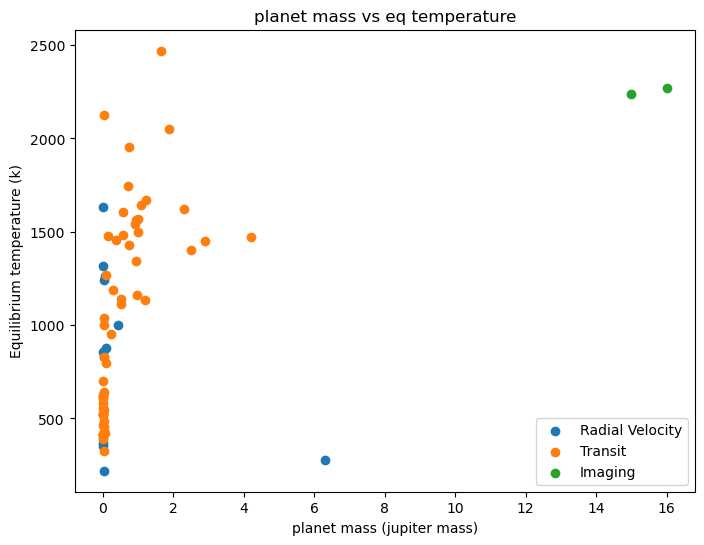

In [40]:
plt.figure(figsize=(8,6))

for method in smaller_df["discoverymethod"].unique(): 
    subset = smaller_df[smaller_df["discoverymethod"] == method]
    plt.scatter(subset["pl_bmassj"], subset["pl_eqt"], label = method)

plt.title("planet mass vs eq temperature")
plt.xlabel("planet mass (jupiter mass)")
plt.ylabel("Equilibrium temperature (k)")
plt.legend()
plt.show()
    
    

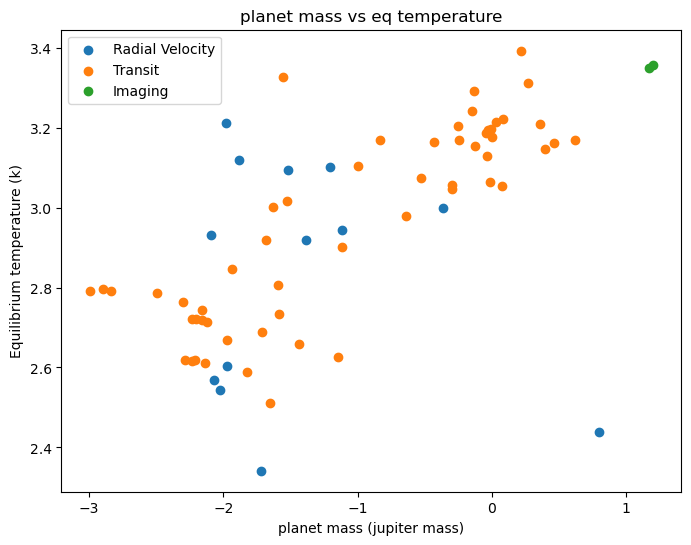

In [41]:
plt.figure(figsize=(8,6))

for method in smaller_df["discoverymethod"].unique(): 
    subset = smaller_df[smaller_df["discoverymethod"] == method]
    plt.scatter(np.log10(subset["pl_bmassj"]), np.log10(subset["pl_eqt"]), label = method)

plt.title("planet mass vs eq temperature")
plt.xlabel("planet mass (jupiter mass)")
plt.ylabel("Equilibrium temperature (k)")
plt.legend()
plt.show()
    

In [42]:
# imaging happens on massive planets as seen from the first plot 

In [43]:
massive_df = smaller_df[smaller_df["pl_bmassj"] >5]

coldest_idx = massive_df["pl_eqt"].idxmin()
coldest_planet = massive_df.loc[coldest_idx]

print (coldest_planet)

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 581, dtype: object


In [44]:
print (coldest_planet["pl_name"])
print (coldest_idx)
print (coldest_planet ["pl_eqt"])
print (coldest_planet["pl_bmassj"])
print (coldest_planet["st_spectype"])
#this is a K type star so it is most likely smaller and cooler than the sun, this is what the spectral type tells us the sizes and temperatures of these start. 


eps Ind A b
581
275.0
6.31
K5 V


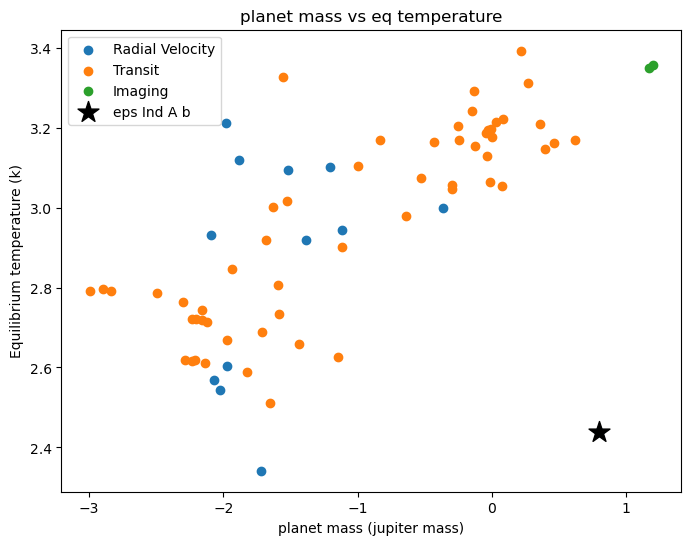

In [45]:
plt.figure(figsize=(8,6))

for method in smaller_df["discoverymethod"].unique(): 
    subset = smaller_df[smaller_df["discoverymethod"] == method]
    plt.scatter(np.log10(subset["pl_bmassj"]), np.log10(subset["pl_eqt"]), label = method)

plt.scatter(np.log10(coldest_planet["pl_bmassj"]),np.log10(coldest_planet["pl_eqt"]),color="black", marker= "*", s = 250, label=coldest_planet["pl_name"])

plt.title("planet mass vs eq temperature")
plt.xlabel("planet mass (jupiter mass)")
plt.ylabel("Equilibrium temperature (k)")
plt.legend()
plt.show()

In [46]:
# a temperature super-jupiter imaged with JWST in the mid infared
# basically JWST was used to image a large exoplanet around a star and they found that it doesnt match the properties of the planet. finding the planet is unusually cool and this could be usefull because it helps to test models of older colder exoplanets. 
# yes planet mathces the one in the paper 
# this planet is special because it is the coldest exoplanet ever directly imaged. its also cool that it talks abotu how the atmosphere on the planet may be intereting and have a stong opacity 
# yes mass and eq temperature both match, whcih makes sense because this is data pulled directly from the nasa directoy. 